# 📊 Business Insights Report
## Sales Performance Dashboard

**Name:** Prisha Kamatkar  
**Course:** TYBCA  
**Internship Task:** Task 1 – Sales Performance Dashboard  
**Date:** 18 August 2026


# 📘 Introduction

This report presents a detailed analysis of sales performance using data visualization and KPI tracking.  
The objective is to identify key business insights across revenue, orders, product categories, payment methods, and regional performance.  

### Goals of the Report
- Provide an **Executive Overview** of overall business performance.  
- Deliver a **Detailed Analysis** of product categories, payment preferences, and state‑wise revenue.  
- Highlight **Business Insights** that can guide decision‑making and operational improvements.  

### Tools & Methods
- **Python (Jupyter Notebook):** Data cleaning, preprocessing, KPI calculations, and chart generation.  
- **Power BI/Tableau:** Interactive dashboards for executive and detailed analysis.  
- **GitHub:** Repository hosting and documentation.  

---


In [ ]:
# Step 1: Load the dataset first
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("data1.csv")   # replace with your file path

# Step 2: Inspect the raw columns
print(df.columns)

# Step 3: Standardize column names
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

# Step 4: Check the updated column names
print(df.columns)



print("Missing values per column:\n", df.isnull().sum())
print("Duplicate rows:", df.duplicated().sum())



In [3]:
print(df.columns.tolist())



['order_id', 'date', 'customer_id', 'product_category', 'product_name', 'quantity', 'unit_price_inr', 'payment_method', 'delivery_status', 'review_rating', 'review_text', 'state', 'country', 'revenue_=_quantity_*_unitprice']


In [4]:
# Create revenue column (if not already created)
df['revenue'] = df['quantity'] * df['unit_price_inr']

# Inspect key columns with correct names
print(df[['date','product_name','state','customer_id','revenue']].head())


         date  product_name      state customer_id    revenue
0  25-01-2025  Cookware Set     Sikkim    CUST2796   51148.82
1  28-08-2025    Hair Dryer  Telangana    CUST9669   19361.41
2  27-02-2025        Tablet   Nagaland    CUST5808  115428.66
3  24-02-2025    Headphones      Assam    CUST5889  190728.60
4  15-06-2025         Saree     Odisha    CUST9005  229704.90


In [5]:
print(df.columns.tolist())




['order_id', 'date', 'customer_id', 'product_category', 'product_name', 'quantity', 'unit_price_inr', 'payment_method', 'delivery_status', 'review_rating', 'review_text', 'state', 'country', 'revenue_=_quantity_*_unitprice', 'revenue']


In [6]:
df = df.drop(columns=['revenue_=quantity_*_unitprice'], errors='ignore')


In [7]:
df['revenue'] = df['quantity'] * df['unit_price_inr']


In [8]:
print(df[['date','product_name','state','customer_id','revenue']].head())


         date  product_name      state customer_id    revenue
0  25-01-2025  Cookware Set     Sikkim    CUST2796   51148.82
1  28-08-2025    Hair Dryer  Telangana    CUST9669   19361.41
2  27-02-2025        Tablet   Nagaland    CUST5808  115428.66
3  24-02-2025    Headphones      Assam    CUST5889  190728.60
4  15-06-2025         Saree     Odisha    CUST9005  229704.90


In [9]:
# Convert date column into proper datetime format
df['date'] = pd.to_datetime(df['date'], format='%d-%m-%Y')

# Create a Year-Month column
df['year_month'] = df['date'].dt.to_period('M')

# Calculate monthly revenue
monthly_revenue = df.groupby('year_month')['revenue'].sum()

# Display monthly revenue
print(monthly_revenue)


year_month
2025-01    92051785.03
2025-02    84995760.62
2025-03    93064349.39
2025-04    91388990.14
2025-05    97195848.48
2025-06    89730685.72
2025-07    95176904.42
2025-08    97576563.09
2025-09    91225555.74
2025-10    93478344.05
2025-11    94809186.29
2025-12    97467830.53
Freq: M, Name: revenue, dtype: float64


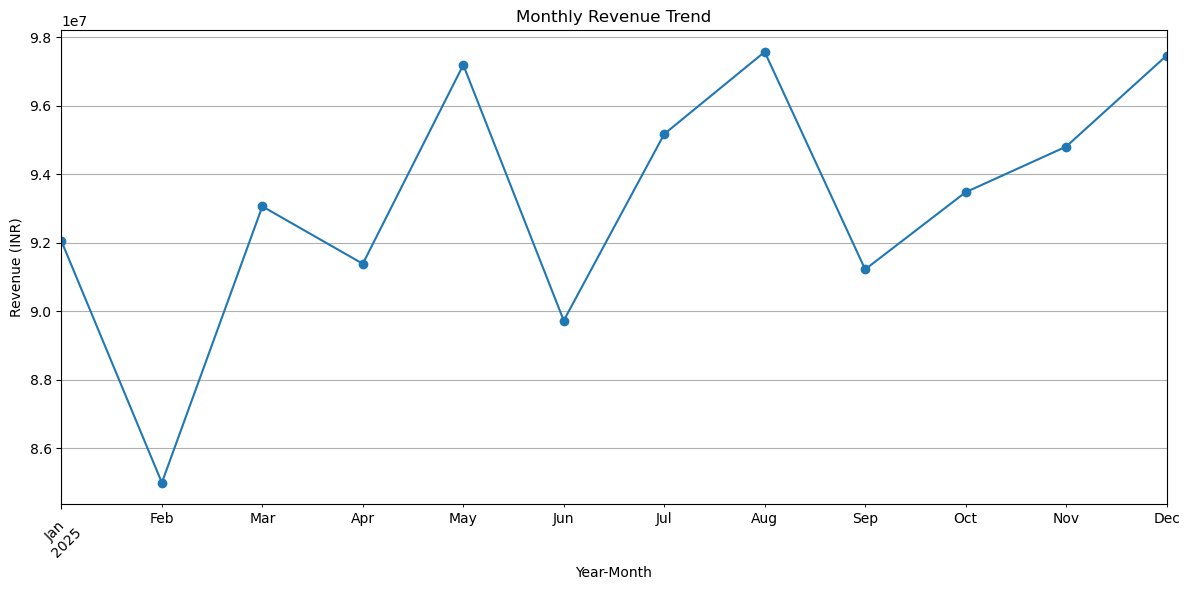

In [10]:
# Plot monthly revenue trend
monthly_revenue.plot(
    kind='line',
    figsize=(12, 6),
    marker='o',
    title='Monthly Revenue Trend'
)

plt.xlabel('Year-Month')
plt.ylabel('Revenue (INR)')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


In [11]:
# Calculate revenue by state
state_sales = (
    df.groupby('state')['revenue']
    .sum()
    .sort_values(ascending=False)
)

# Select top 10 states
top_10_states = state_sales.head(10)

print(top_10_states)

state
Sikkim           43113469.51
Rajasthan        42906175.08
Chhattisgarh     42857545.27
Meghalaya        42773152.96
Tamil Nadu       41967968.99
Uttar Pradesh    41690917.07
Bihar            41669240.44
West Bengal      41195932.45
Tripura          41103376.81
Odisha           40924381.38
Name: revenue, dtype: float64


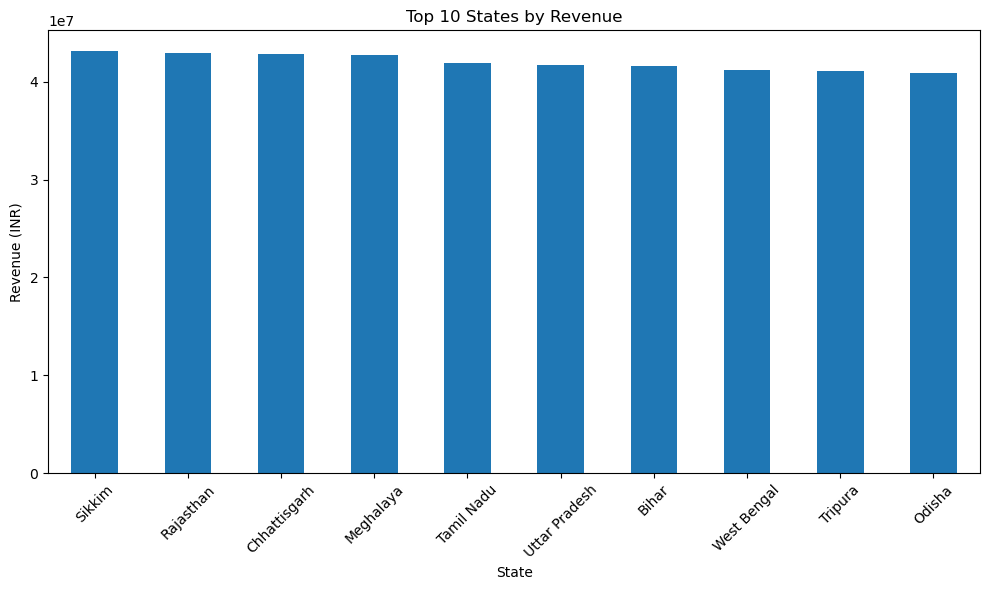

In [12]:
# Plot Top 10 States
top_10_states.plot(
    kind='bar',
    figsize=(10, 6),
    title='Top 10 States by Revenue'
)

plt.xlabel('State')
plt.ylabel('Revenue (INR)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [13]:
# Calculate revenue by product
product_sales = (
    df.groupby('product_name')['revenue']
    .sum()
    .sort_values(ascending=False)
)

# Select top 10 products
top_10_products = product_sales.head(10)

print(top_10_products)

product_name
Lipstick           48159020.15
Children's Book    48145664.52
Headphones         48044405.75
Hair Dryer         47428844.81
Perfume            46284732.62
Laptop             46173868.15
Tablet             46170022.15
Sneakers           46057295.93
Air Fryer          45919707.91
Jeans              45232819.47
Name: revenue, dtype: float64


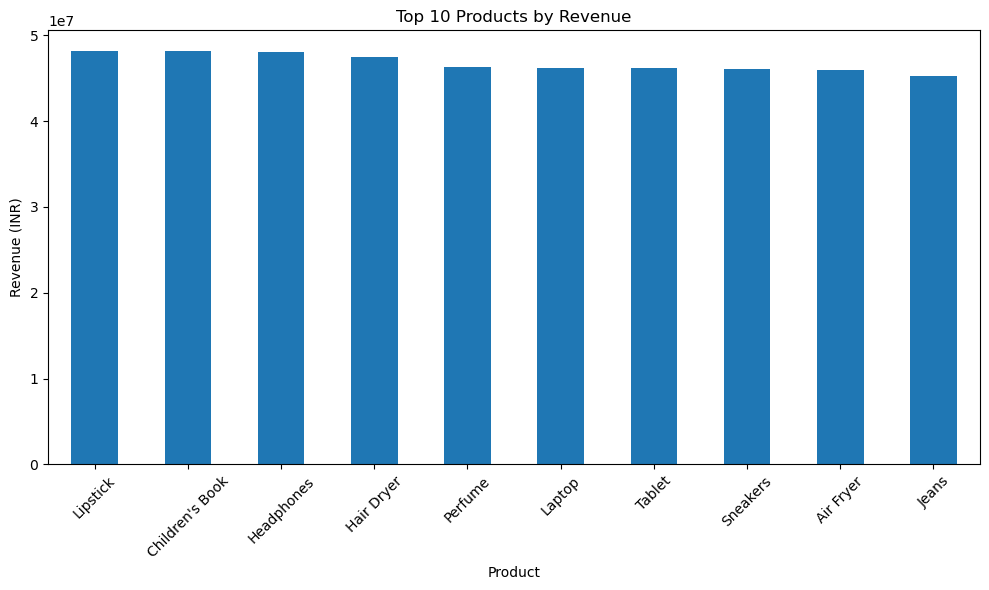

In [14]:
# Plot Top 10 Products by Revenue
top_10_products.plot(
    kind='bar',
    figsize=(10, 6),
    title='Top 10 Products by Revenue'
)

plt.xlabel('Product')
plt.ylabel('Revenue (INR)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [15]:
# Save the final cleaned dataset
df.to_csv("final_sales_data.csv", index=False)

print("Final dataset saved successfully!")

Final dataset saved successfully!


# 📑 Business Insights Summary

- **Revenue Performance:** The business generated a total revenue of ₹1.12bn from 15K orders and 45K items sold.  
- **Customer Spending:** The average order value is ₹74.54K, reflecting strong purchasing behavior.  
- **Top Categories:** Beauty and Electronics are the leading contributors to revenue, showing consistent demand.  
- **Payment Preferences:** Digital payments (Credit Card and UPI) together account for nearly half of total revenue, highlighting customer trust in online transactions.  
- **Regional Trends:** States such as Rajasthan and Sikkim lead in revenue, while other regions show potential for growth.  
- **Delivery Status:** Most orders are delivered successfully, but pending and returned orders (~33%) indicate areas for operational improvement.  

---
**Conclusion:** Overall, the business is performing well with strong product categories and digital adoption. Future focus should be on reducing pending/returned orders and expanding in underperforming states to maximize growth opportunities.
